In [599]:
from escripts import eMCMC
import importlib
from escripts import eplots
Plotting = eplots.Plotting()
from pandas.plotting import table
import zeus21
from escripts import cosmo_calc
from astropy import units as u
from matplotlib.colors import ListedColormap
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
import time

In [600]:
# Get data
datBouw21 = np.loadtxt('/Users/eb35267/Desktop/code/home/data/Bouwens2021_GAL.txt',  skiprows=2, unpack=True)
redshiftsBouw21 = np.unique(datBouw21[0])
dredshiftsBouw21 = np.ones_like(redshiftsBouw21)/2. #approximate, there are true window functions to use

datHST = [] 
#format is     zdat = data[0] zerr = data[1] xdat = data[2],  ydat = data[3]  yerr = data[4]  xerr = data[5] 

for iz,z in enumerate(redshiftsBouw21): # Create a bunch of arrays that contain all of the data listed above. One for each redshift
    zlistindex = datBouw21[0] == 1.0*z
    datarr = [z,dredshiftsBouw21[iz], datBouw21[1][zlistindex], datBouw21[3][zlistindex], datBouw21[4][zlistindex], datBouw21[2][zlistindex]]
    datHST= datHST + [datarr]

In [608]:
datBouw21

array([[ 4.000e+00,  4.000e+00,  4.000e+00,  4.000e+00,  4.000e+00,
         4.000e+00,  4.000e+00,  4.000e+00,  4.000e+00,  4.000e+00,
         4.000e+00,  4.000e+00,  5.000e+00,  5.000e+00,  5.000e+00,
         5.000e+00,  5.000e+00,  5.000e+00,  5.000e+00,  5.000e+00,
         5.000e+00,  5.000e+00,  5.000e+00,  5.000e+00,  6.000e+00,
         6.000e+00,  6.000e+00,  6.000e+00,  6.000e+00,  6.000e+00,
         6.000e+00,  6.000e+00,  6.000e+00,  6.000e+00,  7.000e+00,
         7.000e+00,  7.000e+00,  7.000e+00,  7.000e+00,  7.000e+00,
         7.000e+00,  7.000e+00,  7.000e+00,  7.000e+00,  8.000e+00,
         8.000e+00,  8.000e+00,  8.000e+00,  8.000e+00,  8.000e+00,
         8.000e+00,  9.000e+00,  9.000e+00,  9.000e+00,  9.000e+00,
         9.000e+00,  1.000e+01,  1.000e+01,  1.000e+01,  1.000e+01,
         1.000e+01],
       [-2.269e+01, -2.219e+01, -2.169e+01, -2.119e+01, -2.069e+01,
        -2.019e+01, -1.969e+01, -1.919e+01, -1.869e+01, -1.794e+01,
        -1.694e+01, -1.594e

In [601]:
custom_params = {'dalphadz': {'fit':True}, 'dbetadz':{'fit':True}, 'dlogMcdz': {'fit':True}, 'dlogedz': {'fit': True}, 
                 'dsigdz': {'fit':True}, 'dsigdM':{'fit': True}}

In [602]:
param_data = eMCMC.build_param_data(custom_params)

In [603]:
my_UVLF = eMCMC.UVLF(datHST, param_data)

In [604]:
ICs = my_UVLF.generate_ICs()

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:29: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [607]:
# Run MCMC
t = time.time()
Nsteps=2000
my_UVLF.sampler.run_mcmc(ICs, Nsteps) 
# Get flat sample from the MCMC
samples = my_UVLF.sampler.get_chain(discard = 400, flat=True)
print(time.time()-t)

39.71885108947754


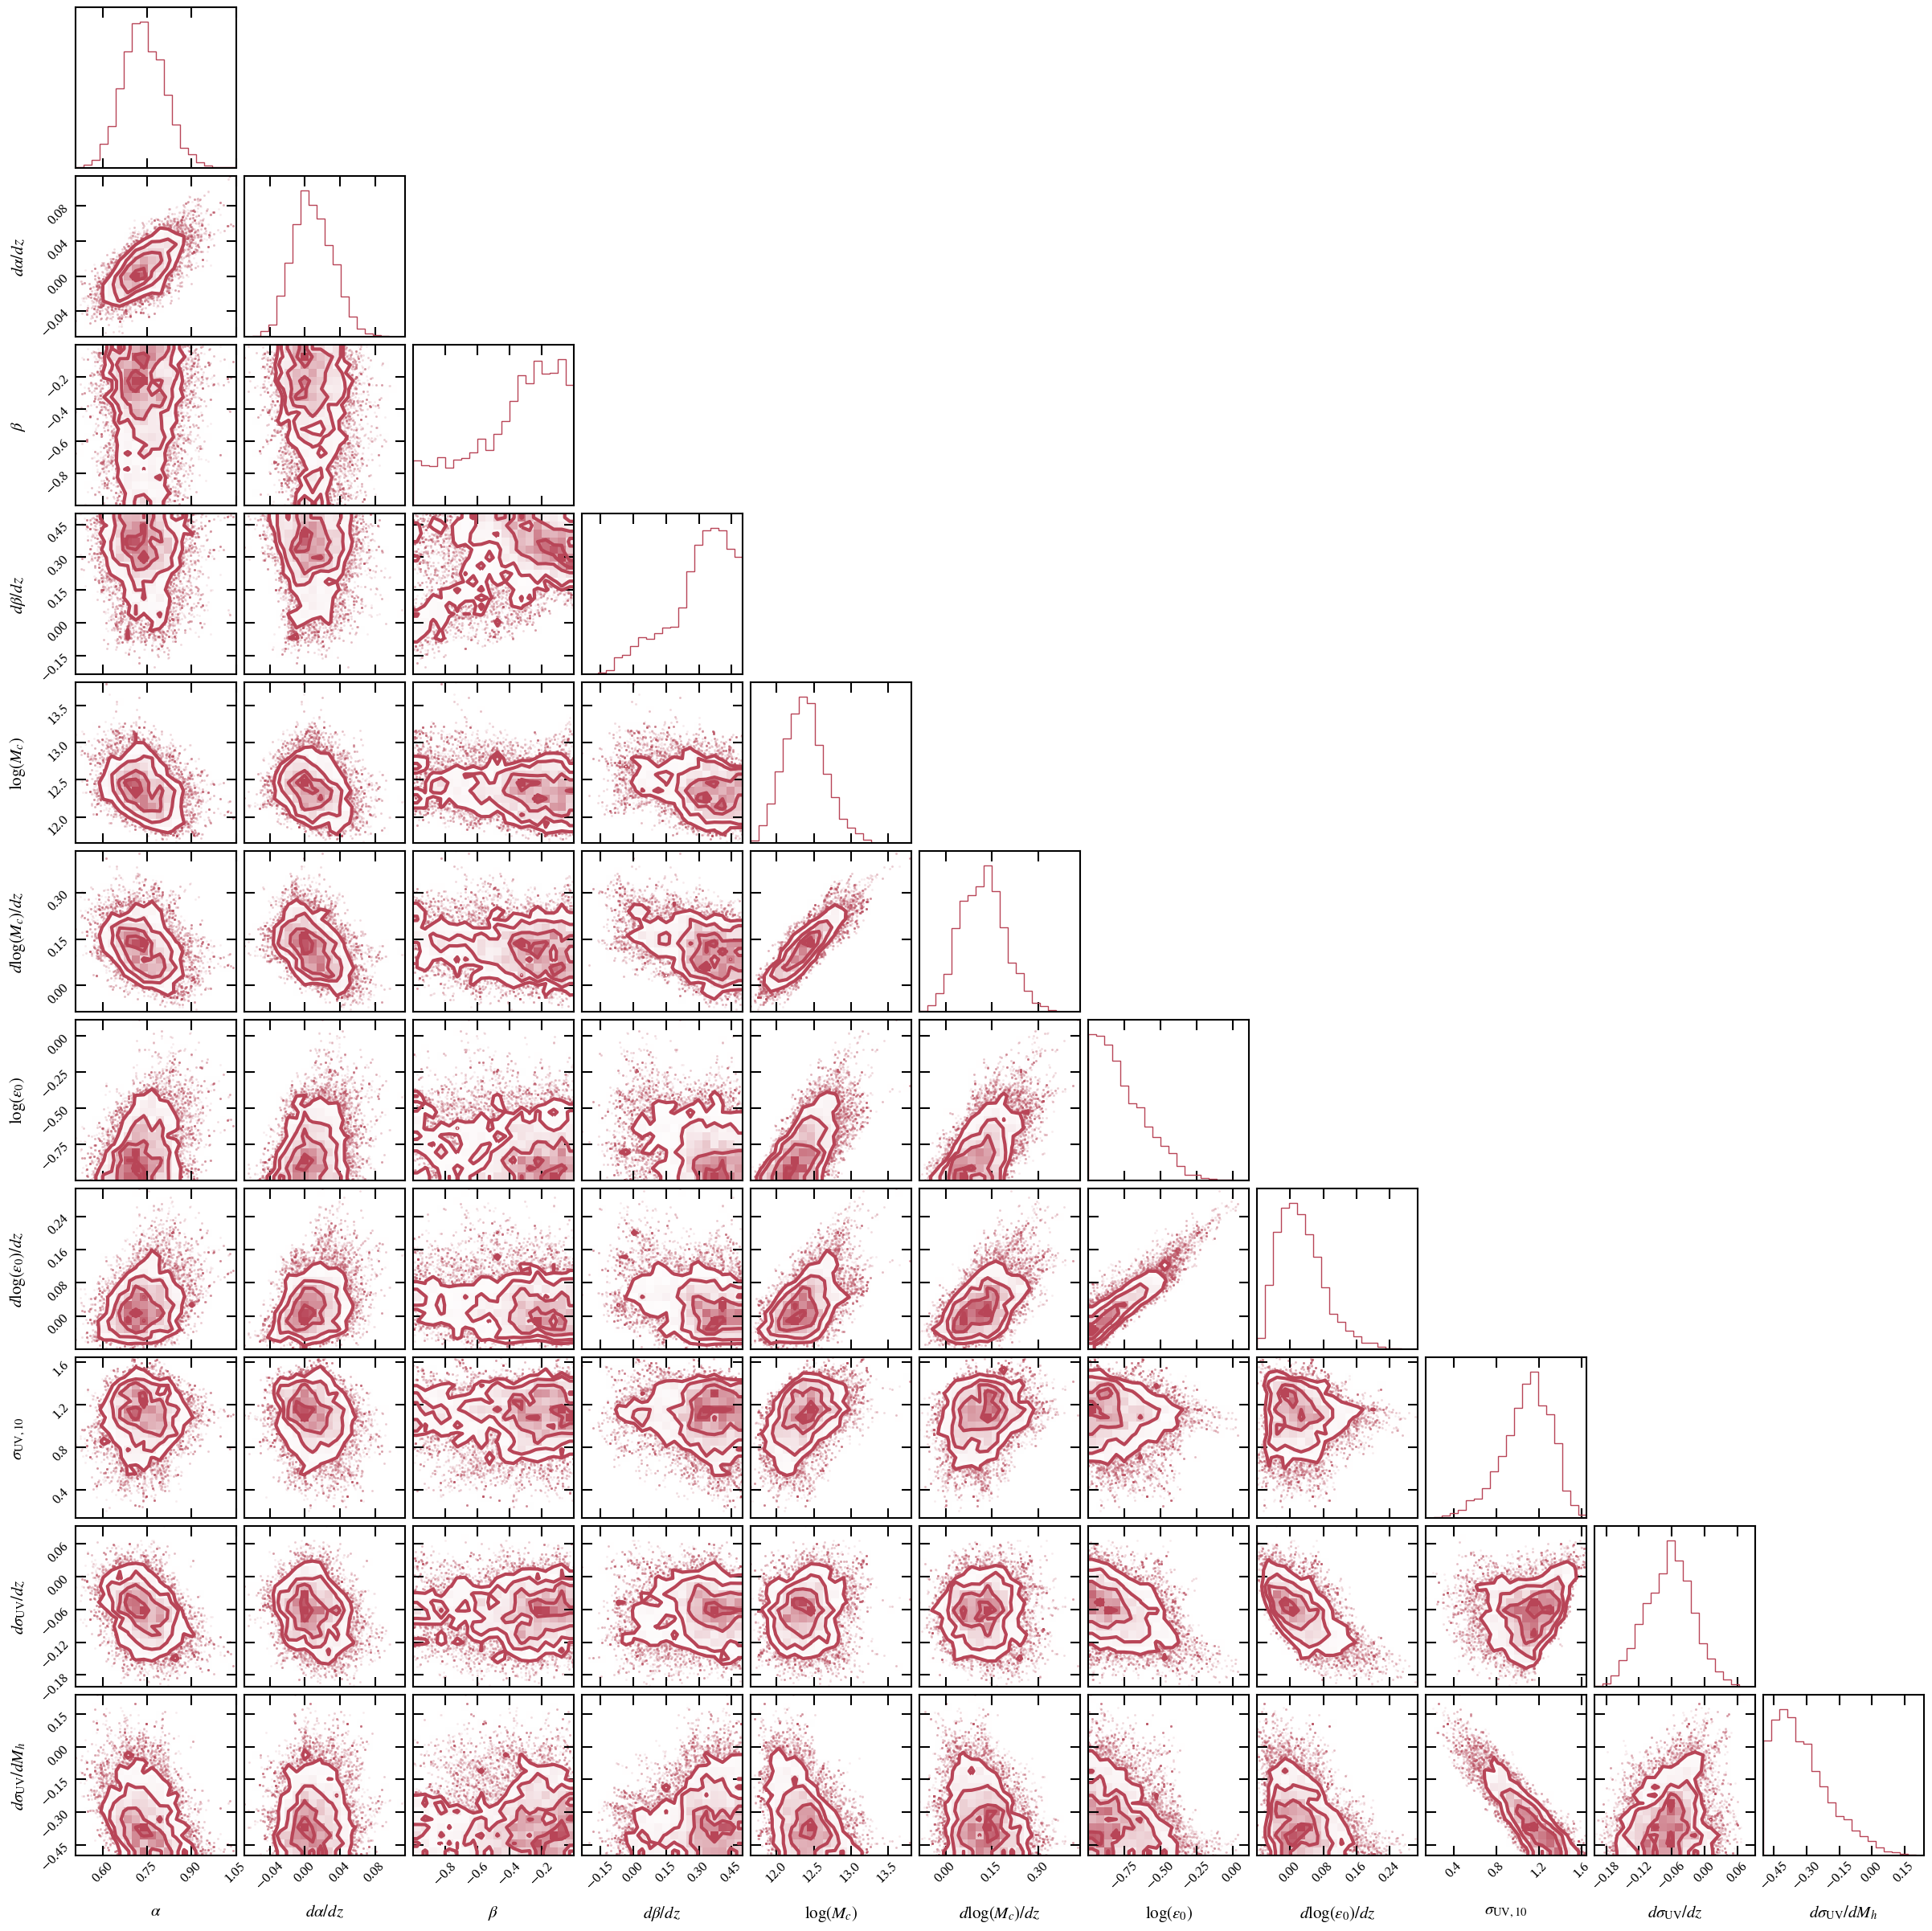

In [29]:
corner = Plotting.plot_corner(samples, my_UVLF)
#corner.savefig('/Users/eb35267/Desktop/figures/ongoing/sig(M,z)/corner.png', bbox_inches='tight')

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:29: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


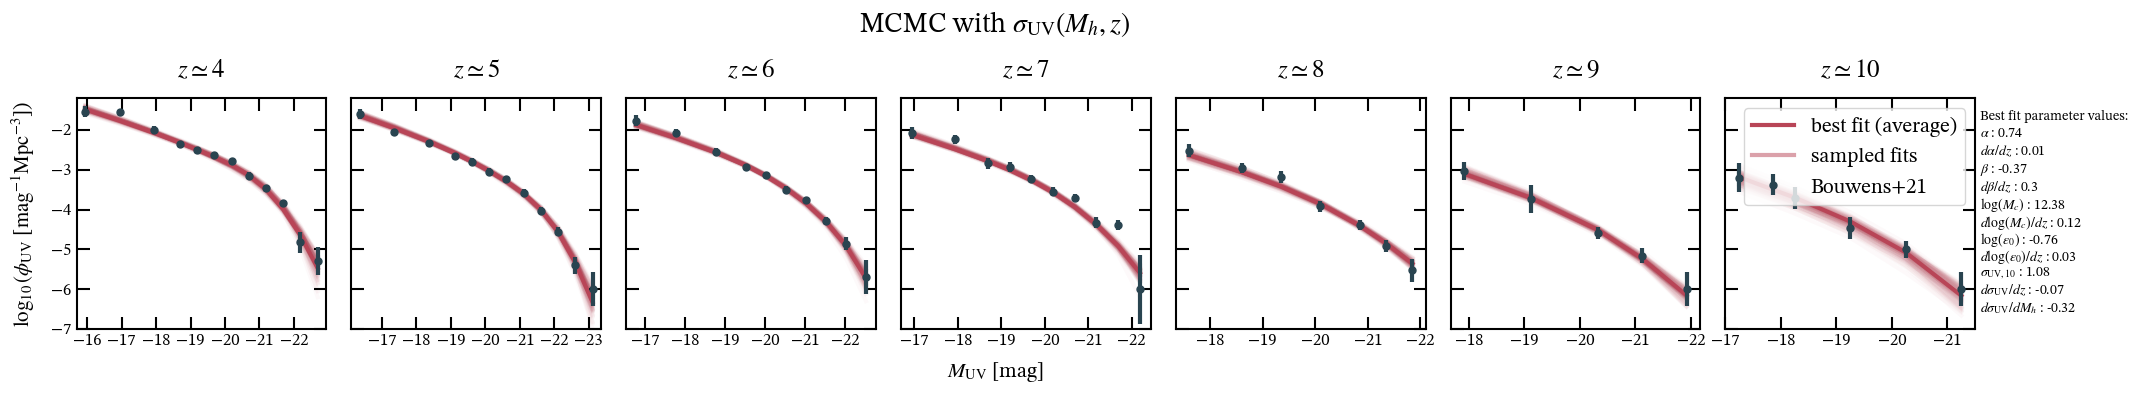

In [34]:
te_plot = Plotting.plot_evolving_UVLF_fit(samples, my_UVLF, title = r'MCMC with $\sigma_{\rm{UV}}(M_h, z)$')
#te_plot.savefig('/Users/eb35267/Desktop/figures/ongoing/sig(M,z)/model.png', bbox_inches='tight')

In [33]:
best_fit, param_labels = my_UVLF.get_best_fit(samples)

In [32]:
jm_conste = [0.61, -0.01, -1.91, 0.08, 12.03, 0.03, '-', '-',  0.65, -0.03, 0]
jm_consts = [.74, 0.03, -1.76, -0.02, 11.84, -0.02, -1.08, -0.07, '-', '-', 0]

In [37]:
df = eMCMC.make_table([best_fit, jm_conste, jm_consts], param_labels, [r'My $\sigma_{\rm{UV}}(M_h, z)$', r'Muñoz+23, piecewise $\epsilon$', r'Muñoz+23, piecewise $\sigma_{\rm{UV}}$'])

In [50]:
df

,"My $\sigma_{\rm{UV}}(M_h, z)$","Muñoz+23, piecewise $\epsilon$","Muñoz+23, piecewise $\sigma_{\rm{UV}}$"
$\alpha$,0.74,0.61,0.74
$d\alpha/dz$,0.01,-0.01,0.03
$\beta$,-0.37,-1.91,-1.76
$d\beta/dz$,0.3,0.08,-0.02
$\log(M_c)$,12.38,12.03,11.84
$d\log(M_c)/dz$,0.12,0.03,-0.02
$\log(\epsilon_0)$,-0.76,-,-1.08
$d\log(\epsilon_0)/dz$,0.03,-,-0.07
"$\sigma_{\rm{UV}, 10}$",1.08,0.65,-
$d\sigma_{\rm{UV}}/dz$,-0.07,-0.03,-


In [52]:
bf_nte = [0.89, 0, -0.86, 0, 11.95, 0, -0.64, 0, 0.34, 0, 0.03]

In [55]:
importlib.reload(eMCMC)

<module 'escripts.eMCMC' from '/Users/eb35267/Desktop/code/home/escripts/eMCMC.py'>

In [57]:
importlib.reload(eplots)
Plotting = eplots.Plotting()

/Users/eb35267/Desktop/code/home/escripts/eplots.py:173: SyntaxWarning: invalid escape sequence '\s'
  
/Users/eb35267/Desktop/code/home/escripts/eplots.py:227: SyntaxWarning: invalid escape sequence '\c'
  
/Users/eb35267/Desktop/code/home/escripts/eplots.py:233: SyntaxWarning: invalid escape sequence '\s'
  


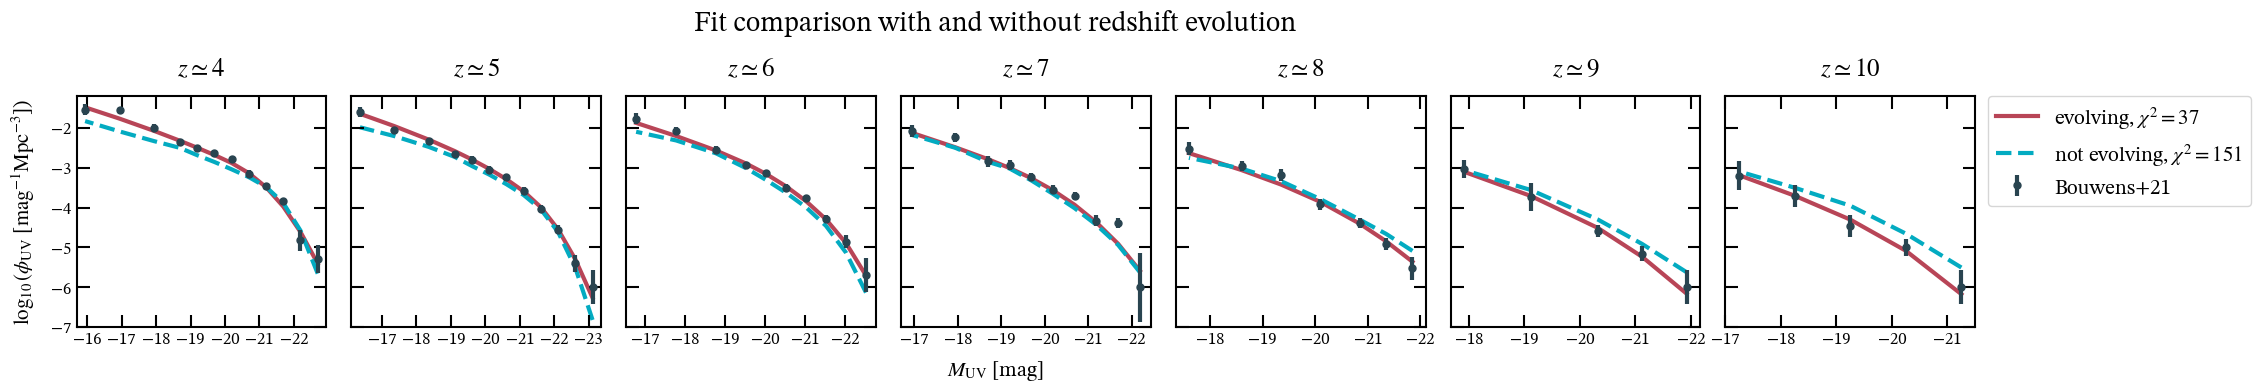

In [64]:
comp_fig = Plotting.compare_fits([best_fit, bf_nte], fit_labels = ['evolving', 'not evolving'], data = datHST, 
                                 title = 'Fit comparison with and without redshift evolution')

In [65]:
#comp_fig.savefig('/Users/eb35267/Desktop/figures/ongoing/sig(M,z)/compare_redshift_ev.png', bbox_inches='tight')

# Interpreting the time evolution of parameters

In [119]:
importlib.reload(cosmo_calc)

<module 'escripts.cosmo_calc' from '/Users/eb35267/Desktop/code/home/escripts/cosmo_calc.py'>

In [120]:
params = cosmo_calc.get_params()

In [122]:
ClassyCosmo, CosmoParams = cosmo_calc.get_CosmoParams(params)

In [124]:
zeus21.Hub??

Signature: zeus21.Hub(Cosmo_Parameters, z)
Docstring: <no docstring>
Source:   
def Hub(Cosmo_Parameters, z):
#Hubble(z) in km/s/Mpc
    return Cosmo_Parameters.h_fid * 100 * np.sqrt(Cosmo_Parameters.OmegaM * pow(1+z,3.)+Cosmo_Parameters.OmegaR * pow(1+z,4.)+Cosmo_Parameters.OmegaL)
File:      ~/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/cosmology.py
Type:      function

In [577]:
steps = 100
def M(z, M0, params, CosmoParams, steps):
    Ms = np.zeros(steps+1)
    Ms[0] = 10**M0
    zs = np.linspace(0, z, steps+1)
    dz = z/(steps+1)
    for i in range(steps):
        # Multiply dM/dt by dt/dz to get M_dot
        M_dot = calc_M_dot(Ms[i], params, zs[i]) / ((1+zs[i]) * (zeus21.Hub(CosmoParams, zs[i])*u.km/(u.s*u.Mpc)).to(u.year**-1).value) 
        # Had to take out a negative here to make it work; not sure why. Normally dt/dz would include a -(1+z)
        Ms[i+1] = Ms[i] - (M_dot * dz)

    return zs, np.log10(Ms)

In [578]:
def calc_M_dot(M_h, params, z = 0):
    return 25.3*(M_h/1e12)**(1.1)*(1+(1.65*z))*np.sqrt((params['Omega_m']*(1+z)**3)+params['Omega_L'])

3


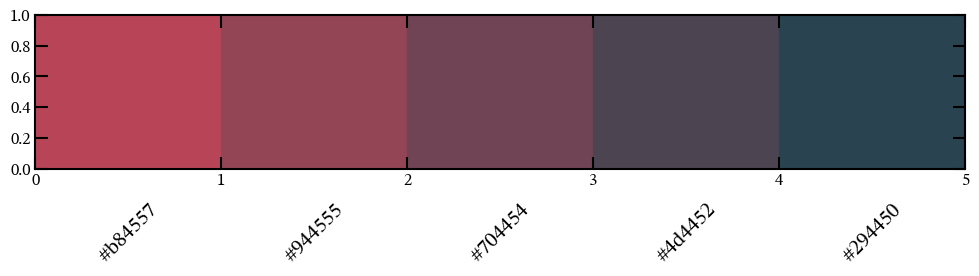

In [579]:
Ms = [10, 11, 12, 13, 14]
gradient, gfig = eplots.interpolate_colors([Plotting.red, Plotting.navy], len(Ms))

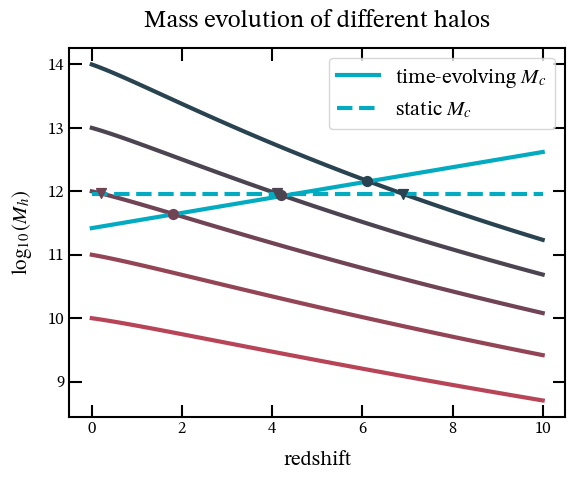

In [596]:
fig, ax = plt.subplots()
cross_ev = []
cross_const = []
for Mi, color in zip(Ms, gradient):
    zi, Ms_i = M(10, Mi, params, CosmoParams, steps = steps)
    ax.plot(zi, Ms_i, ls = 'solid', color = color)
    mc = 12.38 + (zi-8)*0.12
    cross_ev_i = np.where(Ms_i > mc)[0]
    cross_ev.append(cross_ev_i)
    if len(cross_ev_i) >= 1:
        ax.scatter(zi[cross_ev_i][-1], Ms_i[cross_ev_i][-1], zorder = 10, s = 50, color = color)
    cross_const_i = np.where(Ms_i > 11.95)[0]
    cross_const.append(cross_const_i)
    if len(cross_const_i)>=1:
        ax.scatter(zi[cross_const_i][-1], Ms_i[cross_const_i][-1], zorder = 10, s = 50, color = color, marker='v')

ax.plot(zi, mc, color = Plotting.turquoise, label = r'time-evolving $M_c$') 
ax.plot(zi, np.full_like(zi, 11.95), color = Plotting.turquoise, label = 'static $M_c$')
ax.set_xlabel('redshift')
ax.set_ylabel(r'$\log_{10}(M_h)$')
ax.set_title('Mass evolution of different halos')
ax.legend()


#fig.savefig('/Users/eb35267/Desktop/code/figures/sig(M,z)/mass_evolution_of_halos.png', bbox_inches = 'tight')

In [581]:
def calc_evolving_SFE(my_UVLF, best_fit, z, Mh):
    params = my_UVLF.time_evolution(best_fit, z)
    Astro_Parameters = my_UVLF.param_wrapper(params)
    SFE = zeus21.sfrd.fstarofz(Astro_Parameters, my_UVLF.CosmoParams, z, 10**Mh)
    return SFE

In [582]:
fstars = []

for Mh in Ms:
    zs, Mh_i = M(10, Mh, params, CosmoParams, steps = steps)
    fstar_i = [calc_evolving_SFE(my_UVLF, best_fit, z, Mh) for (z, Mh) in zip(zs, Mh_i)]
    fstars.append(fstar_i)

fstars_nte = []

for Mh in Ms:
    zs, Mh_i = M(10, Mh, params, CosmoParams, steps = steps)
    fstar_i = [calc_evolving_SFE(my_UVLF, bf_nte, z, Mh) for (z, Mh) in zip(zs, Mh_i)]
    fstars_nte.append(fstar_i)

In [583]:
cmap = ListedColormap(gradient)

In [584]:
norm = BoundaryNorm(np.arange(min(Ms), max(Ms)+2, 1), cmap.N)

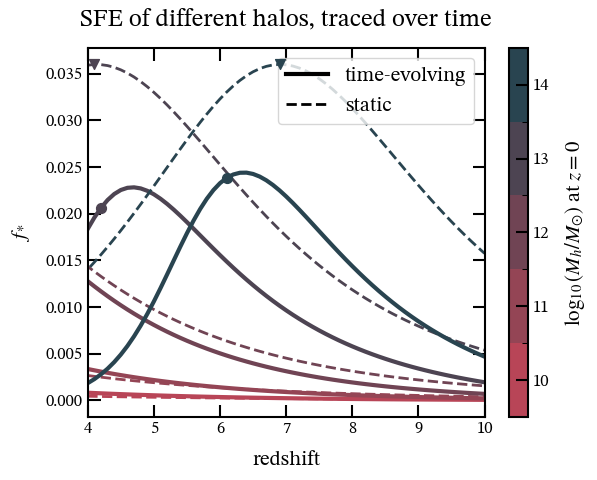

In [598]:
fig, ax = plt.subplots()
for fstari, fstar_nte_i, cross_e, cross_c, Mi in zip(fstars, fstars_nte, cross_ev, cross_const, Ms):
    color = cmap(norm(Mi))
    ax.plot(zs, fstari, ls = '-', color = color)
    ax.plot(zs, fstar_nte_i, ls = 'dashed', color = color, lw = 2)
    if len(cross_e) >=1:
        ax.scatter(zs[cross_e[-1]], fstari[cross_e[-1]], zorder = 10, s = 50, color = color)
    if len(cross_c) >=1:
        ax.scatter(zs[cross_c[-1]], fstar_nte_i[cross_c[-1]], zorder = 10, s = 50, color = color, marker='v')

ax.set_xlim(4, 10)

sm = ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax, ticks=np.array(Ms)+0.5, boundaries=Ms, format='%1i')
cbar.set_label(r'$\log_{10}(M_h/M_{\odot})$ at $z=0$') 

ax.plot(0, 0, ls = '-', color = 'black', label = 'time-evolving')
ax.plot(0,0, ls = 'dashed', lw = 2, color = 'black', label = 'static')
ax.legend()

ax.set_ylabel(r'$f_*$')
ax.set_xlabel('redshift')
ax.set_title('SFE of different halos, traced over time')

#fig.savefig('/Users/eb35267/Desktop/code/figures/sig(M,z)/halo_SFE.png', bbox_inches = 'tight')